In [1]:
import os
import ray
import json
import pickle
from dynaconf import Dynaconf
from tqdm.notebook import tqdm
from utils import check_path, convert_np_arrays, flatten_dict, env_creator
from ray.tune.logger import JsonLogger
from algorithms_with_statistics.ddqn_pber import DDQNWithMPBERAndLogging
from replay_buffer.mpber_ram_saver import MultiAgentPrioritizedBlockReplayBuffer
from ray.tune.registry import register_env

pygame 2.5.2 (SDL 2.28.2, Python 3.9.16)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
# Init Ray
ray.init(
    num_cpus=5, num_gpus=1,
    include_dashboard=False,
    _system_config={"maximum_gcs_destroyed_actor_cached_count": 20},
)

2024-04-18 21:55:02,135	INFO worker.py:1673 -- Started a local Ray instance.


Python version:,3.9.16
Ray version:,2.8.0


(RolloutWorker pid=2695037) /home/seventheli/anaconda3/envs/ber_gym_28/lib/python3.9/site-packages/gymnasium/envs/registration.py:531: UserWarning: WARN: Using the latest versioned environment `MiniGrid-LavaCrossingS9N3-v0` instead of the unversioned environment `MiniGrid-LavaCrossingS9N3`.
(RolloutWorker pid=2695037)   logger.warn(


In [3]:
import mlflow
from mlflow.exceptions import MlflowException
from func_timeout import FunctionTimedOut
from botocore.exceptions import ConnectionClosedError

In [4]:
import datetime
# Config path
env_name = "MiniGrid-LavaCrossingS9N3"
run_name = int(datetime.datetime.now().timestamp())
log_path = "/home/seventheli/data/BER/experiments/logging/%s" % env_name
checkpoint_path = "/home/seventheli/data/BER/experiments/checkpoints/%s" % env_name
# Set mlflow
mlflow.set_tracking_uri("http://localhost:9999")
mlflow.set_experiment(experiment_name=env_name)
mlflow_client = mlflow.tracking.MlflowClient()

In [5]:
# Check path available
import shutil
check_path(log_path)
log_path = str(os.path.join(log_path, str(run_name)))
check_path(log_path)
if os.path.exists(log_path):
    shutil.rmtree(log_path)
check_path(log_path)
check_path(checkpoint_path)
checkpoint_path = os.path.join(checkpoint_path, str(run_name))
check_path(checkpoint_path)
if os.path.exists(checkpoint_path):
    shutil.rmtree(checkpoint_path)
check_path(checkpoint_path)

In [6]:
# Set hyper parameters
setting = "./settings/ddqn_minigrid.yml"
setting = Dynaconf(envvar_prefix="DYNACONF", settings_files=setting)

hyper_parameters = setting.hyper_parameters.to_dict()
hyper_parameters["logger_config"] = {"type": JsonLogger, "logdir": checkpoint_path}
hyper_parameters["env_config"] = {"id": env_name, "tile_size": 10, "img_size": 80, "max_steps": 100}

In [7]:
# Set model
from model import CNN
from ray.rllib.models import ModelCatalog

hyper_parameters["hiddens"] = [128, 128]
model_name = "CNN"
ModelCatalog.register_custom_model(model_name, CNN)
hyper_parameters["model"] = {
    "custom_model": model_name,
    "no_final_linear": True,
    "fcnet_hiddens": hyper_parameters["hiddens"] + [256],
}

In [8]:
# Set run object
run_name = "DDQN_%s" % env_name + "_PBER_RAM_SAVER_%s" % run_name
env_example = env_creator(hyper_parameters["env_config"])
obs, _ = env_example.reset()
step = env_example.step(1)
print(env_example.action_space, env_example.observation_space)
print(env_example)
print("log path: %s; check_path: %s" % (log_path, checkpoint_path))
register_env("MiniGrid", env_creator)

Discrete(7) Box(0, 255, (80, 80, 3), uint8)
<TimeLimit<ResizeObservation<ImgObsWrapper<RGBImgObsWrapper<OrderEnforcing<PassiveEnvCheckerWGWGWGWGWGWGWGWGWG
WGVV    VR      WG
WGVRVR  VRVRVRVRWG
WG              WG
WG      VR      WG
WG      VR      WG
WGVRVRVRVRVRVR  WG
WG      VR    GGWG
WGWGWGWGWGWGWGWGWG>>>>>>
log path: /home/seventheli/data/BER/experiments/logging/MiniGrid-LavaCrossingS9N3/1713473703; check_path: /home/seventheli/data/BER/experiments/checkpoints/MiniGrid-LavaCrossingS9N3/1713473703


/home/seventheli/anaconda3/envs/ber_gym_28/lib/python3.9/site-packages/gymnasium/envs/registration.py:531: UserWarning: WARN: Using the latest versioned environment `MiniGrid-LavaCrossingS9N3-v0` instead of the unversioned environment `MiniGrid-LavaCrossingS9N3`.
  logger.warn(


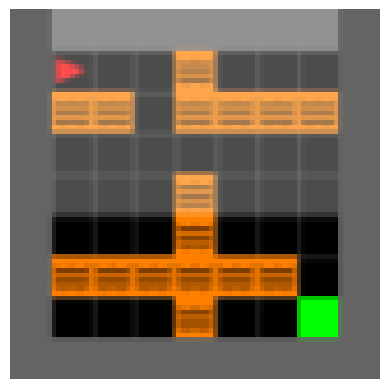

In [9]:
import matplotlib.pyplot as plt

# Plotting the image without the 4th dimension (assuming it's an alpha channel or similar)
plt.imshow(obs)
plt.axis('off')
plt.show()

In [10]:
# Set Replay Buffer
replay_buffer_config = {
    **hyper_parameters["replay_buffer_config"],
    "type": MultiAgentPrioritizedBlockReplayBuffer,
    "obs_space": env_example.observation_space,
    "action_space": env_example.action_space,
    "sub_buffer_size": 8,
    "worker_side_prioritization": False,
    "replay_buffer_shards_colocated_with_driver": True,
    "rollout_fragment_length": hyper_parameters["rollout_fragment_length"],
    "num_save": 50,
    "split_mini_batch": 1,
    "store": 3000
}
hyper_parameters["replay_buffer_config"] = replay_buffer_config
hyper_parameters["optimizer"] = {"num_replay_buffer_shards": 1}

In [11]:
# Set Trainer
trainer = DDQNWithMPBERAndLogging(config=hyper_parameters, env="MiniGrid")

2024-04-18 21:55:03,774	WARNING deprecation.py:50 -- DeprecationWarning: `rllib/algorithms/simple_q/` has been deprecated. Use `rllib_contrib/simple_q/` instead. This will raise an error in the future!
2024-04-18 21:55:03,776	WARNING deprecation.py:50 -- DeprecationWarning: `algo = Algorithm(env='MiniGrid', ...)` has been deprecated. Use `algo = AlgorithmConfig().environment('MiniGrid').build()` instead. This will raise an error in the future!
/home/seventheli/anaconda3/envs/ber_gym_28/lib/python3.9/site-packages/ray/rllib/utils/from_config.py:197: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  object_ = constructor(*ctor_args, **ctor_kwargs)


In [12]:
# Common setup
checkpoint_path = str(checkpoint_path)
# Save initial configuration
with open(os.path.join(checkpoint_path, "%s_config.pyl" % run_name), "wb") as f:
    _ = trainer.config.to_dict()
    pickle.dump(_, f)

In [13]:
mlflow_run = mlflow.start_run(run_name=run_name,
                              tags={"mlflow.user": "Local"})
# Log parameters
mlflow.log_params(hyper_parameters["replay_buffer_config"])
to_log = ['double_q', 'dueling', 'lr', 'n_step', 'num_steps_sampled_before_learning_starts',
          'rollout_fragment_length', 'target_network_update_freq', 'train_batch_size', 'min_sample_timesteps_per_iteration']
mlflow.log_params(
    {key: hyper_parameters[key] for key in to_log})

In [14]:
keys_to_extract_sam = {"episode_reward_max", "episode_reward_min", "episode_reward_mean"}
keys_to_extract_sta = {"num_agent_steps_sampled", "num_agent_steps_trained"}
keys_to_extract_buf = {"add_batch_time_ms", "replay_time_ms", "update_priorities_time_ms"}

In [15]:
mlflow.pytorch.log_model(trainer.get_policy().model, run_name)
model_uri = "runs:/%s/model_name" % mlflow_run.info.run_id
mlflow.register_model(model_uri, run_name, tags={"episode" : 0})

/home/seventheli/anaconda3/envs/ber_gym_28/lib/python3.9/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
INFO:botocore.credentials:Found credentials in shared credentials file: ~/.aws/credentials
Successfully registered model 'DDQN_MiniGrid-LavaCrossingS9N3_PBER_RAM_SAVER_1713473703'.
2024/04/18 21:55:16 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: DDQN_MiniGrid-LavaCrossingS9N3_PBER_RAM_SAVER_1713473703, version 1
Created version '1' of model 'DDQN_MiniGrid-LavaCrossingS9N3_PBER_RAM_SAVER_1713473703'.


<ModelVersion: aliases=[], creation_timestamp=1713473716416, current_stage='None', description='', last_updated_timestamp=1713473716416, name='DDQN_MiniGrid-LavaCrossingS9N3_PBER_RAM_SAVER_1713473703', run_id='6646e3e0e7424e3bac72c807c9fdbb2e', run_link='', source='s3://jo-mlflow-ber/28/6646e3e0e7424e3bac72c807c9fdbb2e/artifacts/model_name', status='READY', status_message='', tags={'episode': '0'}, user_id='', version='1'>

In [16]:
for i in tqdm(range(0, setting.log.max_run), ascii=True):
    result = trainer.train()
    time_used = result["time_total_s"]
    try:
        sampler = result.get("sampler_results", {}).copy()
        eva = result.get("evaluation", {}).copy()
        info = result.get("info", {}).copy()
        sam = {key: sampler[key] for key in keys_to_extract_sam if key in sampler}
        sta = {key: info[key] for key in keys_to_extract_sta if key in info}
        buf = flatten_dict(trainer.local_replay_buffer.stats())
        buf["est_size_gb"] = buf["est_size_bytes"] /1e9
        result['buffer'] = buf
        time_usage = info.get("learner", {}).get("time_usage", {})
        try:
            ex_info = {
                "reward_99" : calculate_adjusted_mean(result['hist_stats']['episode_reward']),
                "time_total_s": result['time_total_s']
            }
        except:
            ex_info = {}
        if eva:
            eva = {"eval_" + key: eva[key] for key in keys_to_extract_sam if key in eva}
        mlflow.log_metrics({**sam, **sta, **buf, **time_usage, **eva}, step=result["episodes_total"])
        if i % (setting.log.log * 50) == 0:
            trainer.save_checkpoint(checkpoint_path)
            mlflow.pytorch.log_model(trainer.get_policy().model, run_name)
            mlflow.register_model(model_uri, run_name, tags={
                "episode" : result["episodes_total"],
                "reward": sam["episode_reward_mean"],
            })
            mlflow.log_artifacts(log_path)
            mlflow.log_artifacts(checkpoint_path)
        if i % 10 == 0:
            tqdm.write("episode %d ; " % result["episodes_total"] +  " ".join(["%s : %f8" % (i, j)for i, j in sam.items()]))
    except FunctionTimedOut:
        tqdm.write("logging failed")
    except MlflowException:
        tqdm.write("logging failed")
    except ConnectionClosedError:
        tqdm.write("logging failed")
    with open(os.path.join(log_path, str(i) + ".json"), "w") as f:
        result["config"] = None
        json.dump(convert_np_arrays(result), f)
    if time_used >= setting.log.max_time:
        break

  0%|          | 0/1000 [00:00<?, ?it/s]

2024-04-18 21:55:16,774	WARNING multi_agent_prioritized_replay_buffer.py:215 -- Adding batches with column `weights` to this buffer while providing weights as a call argument to the add method results in the column being overwritten.
Registered model 'DDQN_MiniGrid-LavaCrossingS9N3_PBER_RAM_SAVER_1713473703' already exists. Creating a new version of this model...
2024/04/18 21:55:53 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: DDQN_MiniGrid-LavaCrossingS9N3_PBER_RAM_SAVER_1713473703, version 2
Created version '2' of model 'DDQN_MiniGrid-LavaCrossingS9N3_PBER_RAM_SAVER_1713473703'.


episode 247 ; episode_reward_max : 0.0000008 episode_reward_min : 0.0000008 episode_reward_mean : 0.0000008


2024-04-18 21:57:59,697	WARNING deprecation.py:50 -- DeprecationWarning: `ray.rllib.execution.train_ops.multi_gpu_train_one_step` has been deprecated. This will raise an error in the future!


episode 2281 ; episode_reward_max : 0.0000008 episode_reward_min : 0.0000008 episode_reward_mean : 0.0000008
episode 3504 ; episode_reward_max : 0.0000008 episode_reward_min : 0.0000008 episode_reward_mean : 0.0000008
episode 4522 ; episode_reward_max : 0.0000008 episode_reward_min : 0.0000008 episode_reward_mean : 0.0000008
episode 5540 ; episode_reward_max : 0.0000008 episode_reward_min : 0.0000008 episode_reward_mean : 0.0000008
episode 6549 ; episode_reward_max : 0.0000008 episode_reward_min : 0.0000008 episode_reward_mean : 0.0000008
episode 7563 ; episode_reward_max : 0.0000008 episode_reward_min : 0.0000008 episode_reward_mean : 0.0000008
episode 8580 ; episode_reward_max : 0.0000008 episode_reward_min : 0.0000008 episode_reward_mean : 0.0000008
episode 9602 ; episode_reward_max : 0.0000008 episode_reward_min : 0.0000008 episode_reward_mean : 0.0000008
episode 10630 ; episode_reward_max : 0.0000008 episode_reward_min : 0.0000008 episode_reward_mean : 0.0000008
episode 11653 ; ep

Registered model 'DDQN_MiniGrid-LavaCrossingS9N3_PBER_RAM_SAVER_1713473703' already exists. Creating a new version of this model...
2024/04/19 03:41:10 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: DDQN_MiniGrid-LavaCrossingS9N3_PBER_RAM_SAVER_1713473703, version 3
Created version '3' of model 'DDQN_MiniGrid-LavaCrossingS9N3_PBER_RAM_SAVER_1713473703'.


episode 67785 ; episode_reward_max : 0.8472228 episode_reward_min : 0.0000008 episode_reward_mean : 0.0074328
episode 68985 ; episode_reward_max : 0.0000008 episode_reward_min : 0.0000008 episode_reward_mean : 0.0000008
episode 70120 ; episode_reward_max : 0.0000008 episode_reward_min : 0.0000008 episode_reward_mean : 0.0000008
episode 71376 ; episode_reward_max : 0.0000008 episode_reward_min : 0.0000008 episode_reward_mean : 0.0000008
episode 72831 ; episode_reward_max : 0.0000008 episode_reward_min : 0.0000008 episode_reward_mean : 0.0000008
episode 74327 ; episode_reward_max : 0.0000008 episode_reward_min : 0.0000008 episode_reward_mean : 0.0000008
episode 75509 ; episode_reward_max : 0.0000008 episode_reward_min : 0.0000008 episode_reward_mean : 0.0000008
episode 76786 ; episode_reward_max : 0.0000008 episode_reward_min : 0.0000008 episode_reward_mean : 0.0000008
episode 78193 ; episode_reward_max : 0.0000008 episode_reward_min : 0.0000008 episode_reward_mean : 0.0000008
episode 79

In [17]:
trainer.save_checkpoint(checkpoint_path)
mlflow.log_artifacts(log_path)
mlflow.log_artifacts(checkpoint_path)

In [18]:
mlflow.end_run()